## Galerkin method and IGA discretization

Restrict to finite dimensional $V_h \subset H_0^1$ with basis $\{N_1, \ldots, N_n\}$, expand $u_h = \sum_i u_i N_i$, get linear system $\mathbf{K}\mathbf{u} = \mathbf{f}$:

$$K_{ij} = \int_\Omega \nabla N_i \cdot \nabla N_j \, dx, \qquad f_j = \int_\Omega f \, N_j \, dx$$


## Poisson equation in PyGismo


In [2]:
from pathlib import Path
import pygismo as gs
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from matplotlib import cm
from iga_utils import (
    gauss_legendre_01,
    get_side_dofs,
    build_multipatch_mapper,
    assemble_poisson_patch,
    assemble_poisson,
    assemble_boundary_integral,
    assemble_boundary_mass,
    assemble_poisson_variable,
)

XML_DIR = Path("geometries")
xml_file = XML_DIR / "curved_channel.xml"  # Try: "square.xml", "trapezoid.xml", "curved_channel.xml", "TUDflame.xml"
square_xml = XML_DIR / "square.xml"

# Load geometry from XML file

mp = gs.core.gsMultiPatch()
gs.io.gsReadFile(str(xml_file), mp)

print(f"Loaded geometry: {xml_file}")
print(f"  Number of patches: {mp.nPatches()}")
for p_idx in range(mp.nPatches()):
    pa = mp.patch(p_idx)
    print(f"  Patch {p_idx}: degree ({pa.basis().degree(0)},{pa.basis().degree(1)}), "
          f"{pa.basis().size()} DOFs")

Loaded geometry: geometries/curved_channel.xml
  Number of patches: 1
  Patch 0: degree (2,2), 12 DOFs


We perform $p$-refinement (degree elevation) and $h$-refinement (knot insertion) to build a richer approximation space:

In [3]:
# p-refinement (increase degree) + h-refinement (insert knots)
num_refine = 3

mp.degreeElevate(1)       # increase degree by 1
mp.uniformRefine(num_refine)  # uniform knot insertion

n_patches = mp.nPatches()
print(f"After refinement ({n_patches} patch{'es' if n_patches > 1 else ''}):")
total_local_dofs = 0
for p_idx in range(n_patches):
    pa = mp.patch(p_idx)
    ba = pa.basis()
    ne0 = ba.knots(0).numElements()
    ne1 = ba.knots(1).numElements()
    print(f"  Patch {p_idx}: p=({ba.degree(0)},{ba.degree(1)}), "
          f"{ba.component(0).size()}x{ba.component(1).size()}={ba.size()} DOFs, "
          f"{ne0}x{ne1} elements")
    total_local_dofs += ba.size()

# For single-patch convenience (used later)
patch = mp.patch(0)
basis = patch.basis()
p = basis.degree(0)
print(f"\nTotal local DOFs (before interface coupling): {total_local_dofs}")

After refinement (1 patch):
  Patch 0: p=(3,3), 12x7=84 DOFs, 8x4 elements

Total local DOFs (before interface coupling): 84


Visualize the physical domain and IGA mesh (mapped knot lines):

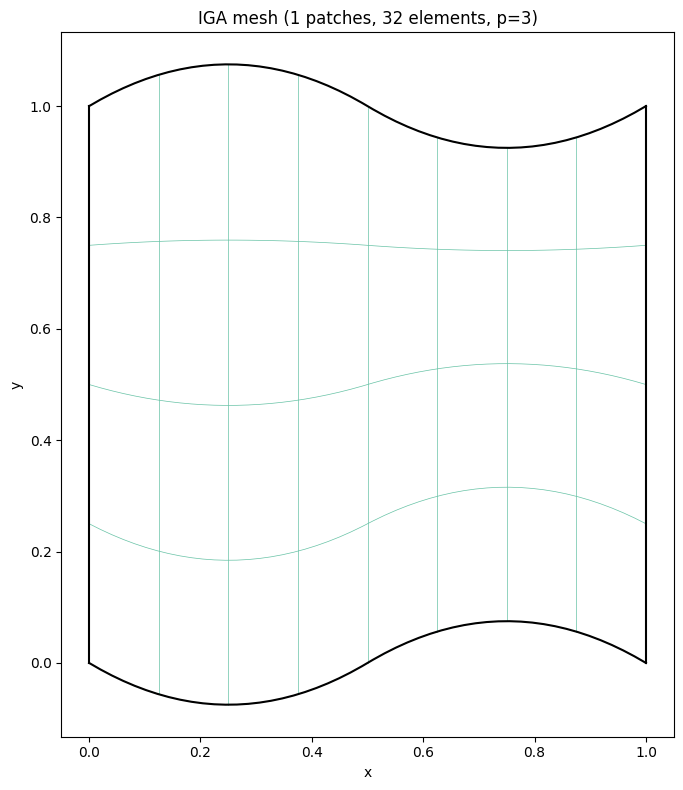

In [4]:
# Plot the physical domain and mesh lines for all patches
npts = 50
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
patch_colors = plt.cm.Set2(np.linspace(0, 1, max(mp.nPatches(), 3)))

for p_idx in range(mp.nPatches()):
    pa = mp.patch(p_idx)
    ba = pa.basis()
    color = patch_colors[p_idx % len(patch_colors)]

    unique_xi = sorted(set(ba.knots(0).get()))
    unique_eta = sorted(set(ba.knots(1).get()))
    xi = np.linspace(0, 1, npts)
    eta = np.linspace(0, 1, npts)

    for xi_val in unique_xi:
        pts_phys = pa.eval(np.array([np.full(npts, xi_val), eta]))
        ax.plot(pts_phys[0], pts_phys[1], '-', color=color, lw=0.5)

    for eta_val in unique_eta:
        pts_phys = pa.eval(np.array([xi, np.full(npts, eta_val)]))
        ax.plot(pts_phys[0], pts_phys[1], '-', color=color, lw=0.5)

    # Patch boundary in thick black
    for val in [0.0, 1.0]:
        pts = pa.eval(np.array([np.full(npts, val), eta]))
        ax.plot(pts[0], pts[1], 'k-', lw=1.5)
        pts = pa.eval(np.array([xi, np.full(npts, val)]))
        ax.plot(pts[0], pts[1], 'k-', lw=1.5)

ax.set_aspect('equal')
n_el_total = sum(mp.patch(i).basis().knots(0).numElements() * mp.patch(i).basis().knots(1).numElements()
                 for i in range(mp.nPatches()))
ax.set_title(f'IGA mesh ({mp.nPatches()} patches, {n_el_total} elements, p={p})')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

Source term and boundary conditions. `gsFunctionExpr` parses symbolic expressions (`x`, `y`, `pi`, `sin`, ...).

In [5]:
# Define source term using gsFunctionExpr
f_expr = gs.core.gsFunctionExpr('1', 2)  # constant source (works on any domain)

# For square domain with known exact solution, use:
# f_expr = gs.core.gsFunctionExpr('2*pi*pi*sin(pi*x)*sin(pi*y)', 2)
# u_ex_expr = gs.core.gsFunctionExpr('sin(pi*x)*sin(pi*y)', 2)

print(f"Source term: f = 1")
print(f"Boundary conditions: homogeneous Dirichlet on all exterior boundaries")

Source term: f = 1
Boundary conditions: homogeneous Dirichlet on all exterior boundaries


## Assembling the stiffness matrix and load vector

Gaussian quadrature element-by-element. At each point $\boldsymbol{\xi}_q$: evaluate $N_i$, $\nabla_\xi N_i$, compute $\mathbf{J}$, transform to physical gradients $\nabla_x N_i = \mathbf{J}^{-T} \nabla_\xi N_i$, accumulate.

In [6]:
# Assembly helpers live in iga_utils.py


Compute the stiffness matrix and right hand side vector:

In [7]:
import time
t0 = time.time()

# Assemble
if mp.nPatches() > 1:
    mapper = build_multipatch_mapper(mp)
    K, F, mapper = assemble_poisson(mp, f_expr, mapper=mapper)
else:
    K, F, mapper = assemble_poisson(mp, f_expr)

n_global = mapper.size()
t_asm = time.time() - t0

print(f"Global DOFs: {n_global} (free: {mapper.freeSize(0)}, boundary: {mapper.boundarySize()})")
print(f"Stiffness matrix K: {K.shape}, nnz = {K.nnz}")
print(f"Assembly time: {t_asm:.2f}s")

Global DOFs: 84 (free: 50, boundary: 34)
Stiffness matrix K: (84, 84), nnz = 2590
Assembly time: 0.16s


Sparsity pattern of the stiffness matrix:

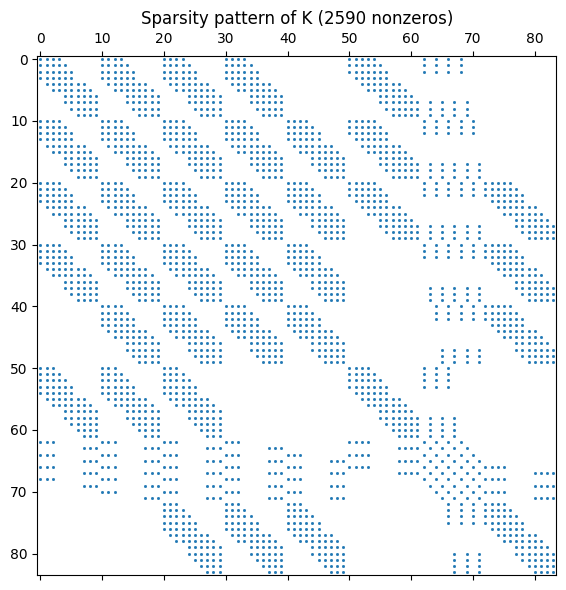

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.spy(K, markersize=1)
ax.set_title(f'Sparsity pattern of K ({K.nnz} nonzeros)')
plt.tight_layout()
plt.show()

## Solve the linear system

Mark the boundary DOFs, eliminate them, and solve:

In [9]:
# Collect free and boundary DOFs
n_global = mapper.size()

if hasattr(mapper, 'is_free'):
    # gsDofMapper case
    inner_dofs = []
    bdry_dofs_set = set()
    for p_idx in range(mp.nPatches()):
        for d in range(mp.patch(p_idx).basis().size()):
            g = mapper.index(d, p_idx, 0)
            if mapper.is_free(d, p_idx, 0):
                inner_dofs.append(g)
            else:
                bdry_dofs_set.add(g)
    inner_dofs = sorted(set(inner_dofs))
    bdry_list = sorted(bdry_dofs_set)
else:
    # Single-patch fallback
    n0 = basis.component(0).size()
    n1 = basis.component(1).size()
    bdry_set = set()
    for j in range(n1):
        bdry_set.add(j * n0)
        bdry_set.add(j * n0 + n0 - 1)
    for i in range(n0):
        bdry_set.add(i)
        bdry_set.add((n1 - 1) * n0 + i)
    bdry_list = sorted(bdry_set)
    inner_dofs = sorted(set(range(n_global)) - bdry_set)

print(f"DOFs: {n_global} total, {len(bdry_list)} boundary, {len(inner_dofs)} free")

# Homogeneous Dirichlet data
u_coeffs = np.zeros(n_global)

# Solve on the free DOFs
F_mod = F[inner_dofs] - K[np.ix_(inner_dofs, bdry_list)] @ u_coeffs[bdry_list]
K_mod = K[np.ix_(inner_dofs, inner_dofs)]
u_coeffs[inner_dofs] = spsolve(K_mod.tocsc(), F_mod)

print(f"Coefficient range: [{u_coeffs.min():.6f}, {u_coeffs.max():.6f}]")

DOFs: 84 total, 34 boundary, 50 free
Coefficient range: [0.000000, 0.077120]


## Visualize the solution

We evaluate $u_h(\boldsymbol{\xi}) = \sum_i u_i N_i(\boldsymbol{\xi})$ on a grid and compare with the exact solution:

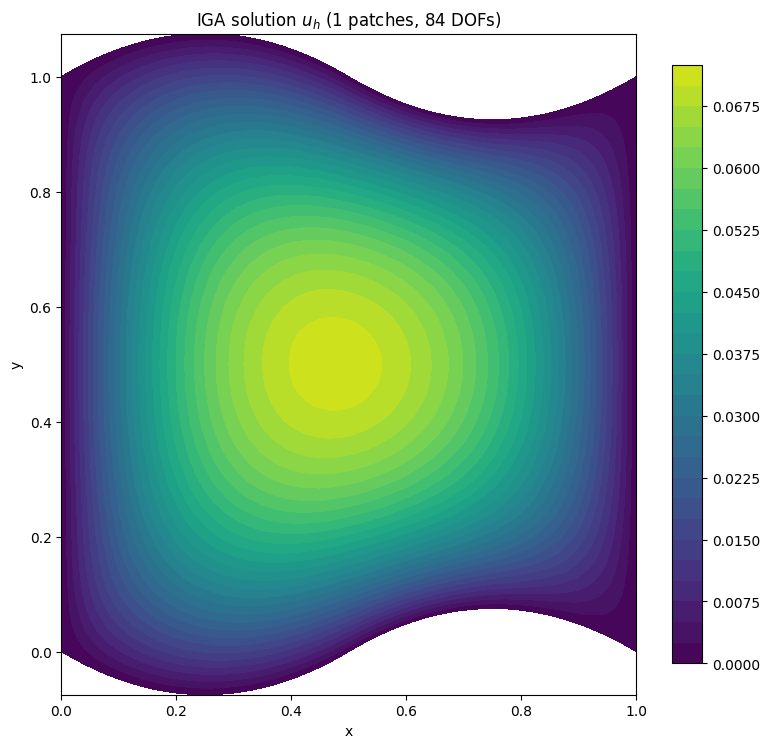

Solution range: [0.000000, 0.077120]


In [10]:
# Evaluate and visualize the IGA solution on all patches
nplot = 50
fig, ax = plt.subplots(figsize=(8, 8))

all_u_vals = []

for p_idx in range(mp.nPatches()):
    pa = mp.patch(p_idx)
    ba = pa.basis()

    XI_p, ETA_p = np.meshgrid(np.linspace(0, 1, nplot), np.linspace(0, 1, nplot))
    params_p = np.array([XI_p.ravel(), ETA_p.ravel()])

    u_h_p = np.zeros(nplot * nplot)
    for k in range(nplot * nplot):
        pt = params_p[:, k:k+1]
        act_local = ba.active(pt).flatten()
        N = ba.eval(pt).flatten()
        # Map local DOFs to global
        gdofs = [mapper.index(int(d), p_idx, 0) for d in act_local]
        u_h_p[k] = np.dot(N, u_coeffs[gdofs])

    xy_p = pa.eval(params_p)
    X_p = xy_p[0].reshape(nplot, nplot)
    Y_p = xy_p[1].reshape(nplot, nplot)
    U_p = u_h_p.reshape(nplot, nplot)
    all_u_vals.append(U_p)

    # Use consistent color range (computed after first pass)
    ax.contourf(X_p, Y_p, U_p, levels=30, cmap=cm.viridis,
                vmin=u_coeffs.min(), vmax=u_coeffs.max())

# Add colorbar from last contourf
c = ax.contourf(X_p, Y_p, U_p, levels=30, cmap=cm.viridis,
                vmin=u_coeffs.min(), vmax=u_coeffs.max())
plt.colorbar(c, ax=ax, shrink=0.8)

ax.set_title(f'IGA solution $u_h$ ({mp.nPatches()} patches, {n_global} DOFs)')
ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

print(f"Solution range: [{u_coeffs.min():.6f}, {u_coeffs.max():.6f}]")

## B-spline basis functions

B-splines have $C^{p-1}$ smoothness (vs $C^0$ for FEM hat functions):

Basis for visualization: 60 DOFs, degree p=3


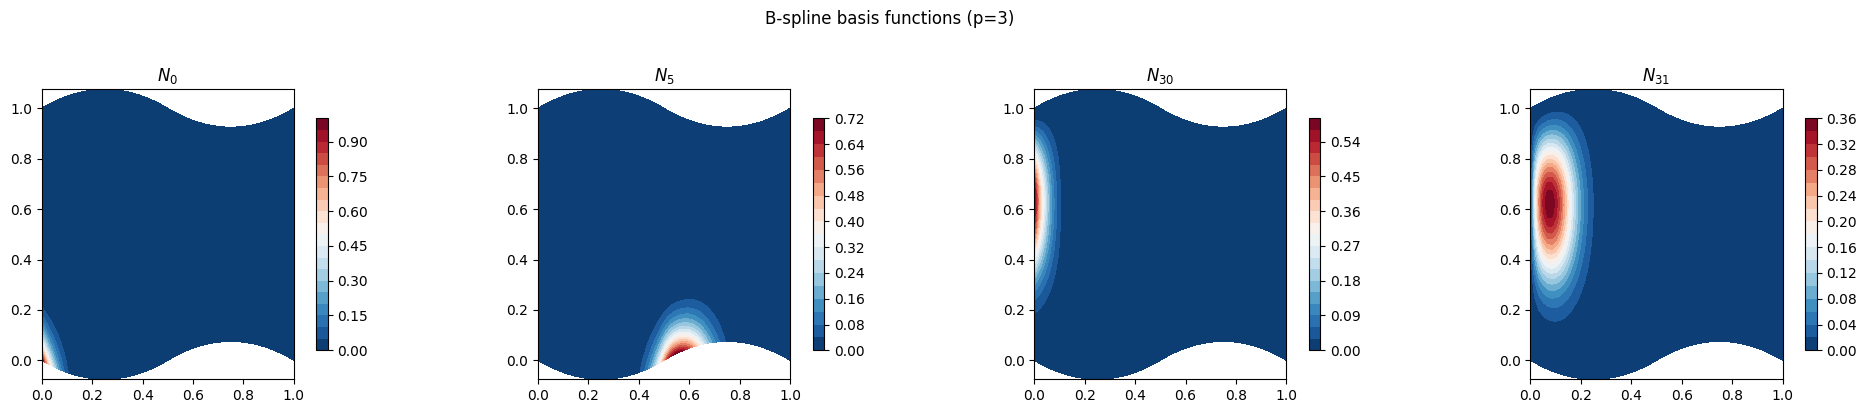

In [11]:
# Pick a few interior basis functions to visualize
# Use a coarser mesh for clarity
mp_vis = gs.core.gsMultiPatch()
gs.io.gsReadFile(str(xml_file), mp_vis)
mp_vis.degreeElevate(1)
mp_vis.uniformRefine(2)

patch_vis = mp_vis.patch(0)
basis_vis = patch_vis.basis()
n_vis = basis_vis.size()
n0_vis = basis_vis.component(0).size()

print(f"Basis for visualization: {n_vis} DOFs, degree p={basis_vis.degree(0)}")

# Evaluate a few basis functions
nplot = 60
XI, ETA = np.meshgrid(np.linspace(0, 1, nplot), np.linspace(0, 1, nplot))
params = np.array([XI.ravel(), ETA.ravel()])
xy_phys = patch_vis.eval(params)
X_vis = xy_phys[0].reshape(nplot, nplot)
Y_vis = xy_phys[1].reshape(nplot, nplot)

# Select 4 basis functions: a corner, edge, and interior one
dof_indices = [0, n0_vis // 2, n_vis // 2, n_vis // 2 + 1]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, dof_idx in zip(axes, dof_indices):
    N_vals = np.zeros(nplot * nplot)
    for k in range(nplot * nplot):
        pt = params[:, k:k+1]
        act = basis_vis.active(pt).flatten()
        N = basis_vis.eval(pt).flatten()
        if dof_idx in act:
            loc = np.where(act == dof_idx)[0][0]
            N_vals[k] = N[loc]
    N_grid = N_vals.reshape(nplot, nplot)
    c = ax.contourf(X_vis, Y_vis, N_grid, levels=20, cmap=cm.RdBu_r)
    ax.set_title(f'$N_{{{dof_idx}}}$')
    ax.set_aspect('equal')
    plt.colorbar(c, ax=ax, shrink=0.8)

plt.suptitle(f'B-spline basis functions (p={basis_vis.degree(0)})', y=1.02)
plt.tight_layout()
plt.show()

# Boundary Conditions

$\partial\Omega = \Gamma_D \cup \Gamma_N \cup \Gamma_R$

* **Dirichlet**: $u = u_D$ on $\Gamma_D$ (prescribed temperature)
* **Neumann**: $\frac{\partial u}{\partial n} = g$ on $\Gamma_N$ (prescribed flux, $g=0$ for insulation)
* **Robin**: $\alpha u + \frac{\partial u}{\partial n} = \alpha u_0$ on $\Gamma_R$ (heat transmission)

## Natural boundary conditions

Neumann and Robin BCs enter the variational form naturally. Replace $\frac{\partial u}{\partial n}$ by the BC:

$$A(u,v) = \int_\Omega \nabla u \cdot \nabla v \, dx + \int_{\Gamma_R} \alpha \, u \, v \, ds$$

$$f(v) = \int_\Omega f \, v \, dx + \int_{\Gamma_N} g \, v \, ds + \int_{\Gamma_R} \alpha u_0 \, v \, ds$$

On a parametric boundary (e.g. $\xi = 1$): $ds = \left| \frac{\partial \mathbf{G}}{\partial \eta} \right| d\eta$

In [12]:
# Boundary-condition helpers live in iga_utils.py


### Example: Mixed boundary conditions

Heat conduction on $[0,1]^2$: Neumann $g=10$ on right, Robin $\alpha=10$, $u_0=293$ on bottom, insulated left/top.

```python
# NGSolve equivalent:
a = BilinearForm(grad(u)*grad(v)*dx + alpha*u*v*ds("bottom"))
f = LinearForm(g*v*ds("right") + alpha*u0*v*ds("bottom"))
```

In [13]:
# Set up the mixed BC problem
mp_bc = gs.core.gsMultiPatch()
gs.io.gsReadFile(str(square_xml), mp_bc)
mp_bc.degreeElevate(1)
mp_bc.uniformRefine(4)

patch_bc = mp_bc.patch(0)
basis_bc = patch_bc.basis()
n_dofs_bc = basis_bc.size()

alpha = 10
u0 = 293
g = 10

# In NGSolve:
#   a = BilinearForm(grad(u)*grad(v)*dx + alpha*u*v*ds("bottom"))
#   f = LinearForm(g*v*ds("right") + alpha*u0*v*ds("bottom"))

# In IGA we assemble the boundary integrals explicitly:
f_zero = gs.core.gsFunctionExpr('0', 2)
K_bc, F_bc, _ = assemble_poisson(mp_bc, f_zero)

# Robin on bottom: add alpha * u * v boundary mass
K_robin = assemble_boundary_mass(patch_bc, basis_bc, 'south', lambda x, y: alpha)
K_bc = K_bc + K_robin

# Neumann on right: g * v boundary integral
F_neumann = assemble_boundary_integral(patch_bc, basis_bc, 'east', lambda x, y: g)
# Robin RHS on bottom: alpha * u0 * v
F_robin = assemble_boundary_integral(patch_bc, basis_bc, 'south', lambda x, y: alpha * u0)
F_bc = F_bc + F_neumann + F_robin

# No Dirichlet boundary — solve the full system
# In NGSolve: gfu.vec.data = a.mat.Inverse() * f.vec
u_bc = spsolve(K_bc.tocsc(), F_bc)
print(f"Temperature range: [{u_bc.min():.1f}, {u_bc.max():.1f}]")

Temperature range: [291.4, 305.4]


The temperature:

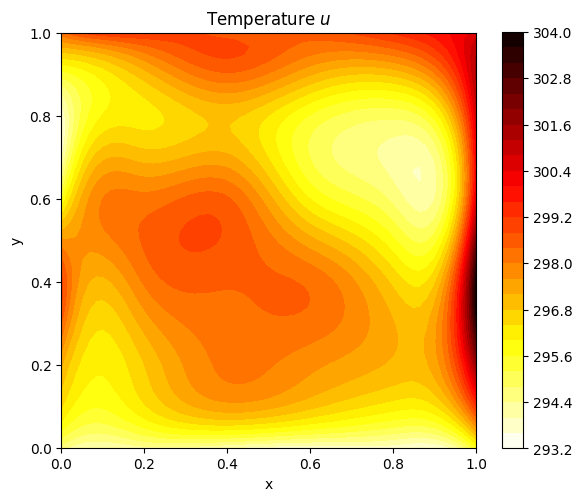

In [14]:
# Evaluate temperature on plot grid
# In NGSolve: Draw(gfu, mesh)
nplot = 60
XI_bc, ETA_bc = np.meshgrid(np.linspace(0, 1, nplot), np.linspace(0, 1, nplot))
params_bc = np.array([XI_bc.ravel(), ETA_bc.ravel()])

u_h_bc = np.zeros(nplot * nplot)
grad_x_bc = np.zeros(nplot * nplot)
grad_y_bc = np.zeros(nplot * nplot)

for k in range(nplot * nplot):
    pt = params_bc[:, k:k+1]
    act = basis_bc.active(pt).flatten()
    N = basis_bc.eval(pt).flatten()
    u_h_bc[k] = np.dot(N, u_bc[act])
    dN = basis_bc.deriv(pt).flatten().reshape(len(act), 2)
    J = patch_bc.jacobian(pt)
    Jinv_T = np.linalg.inv(J).T
    grad_phys = (Jinv_T @ dN.T).T
    grad_u = grad_phys.T @ u_bc[act]
    grad_x_bc[k] = grad_u[0]
    grad_y_bc[k] = grad_u[1]

xy_bc = patch_bc.eval(params_bc)
X_bc = xy_bc[0].reshape(nplot, nplot)
Y_bc = xy_bc[1].reshape(nplot, nplot)
U_bc = u_h_bc.reshape(nplot, nplot)
GX_bc = grad_x_bc.reshape(nplot, nplot)
GY_bc = grad_y_bc.reshape(nplot, nplot)

fig, ax = plt.subplots(figsize=(6, 5))
c = ax.contourf(X_bc, Y_bc, U_bc, levels=30, cmap=cm.hot_r)
ax.set_title('Temperature $u$')
ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(c, ax=ax)
plt.tight_layout()
plt.show()

The heat flux:

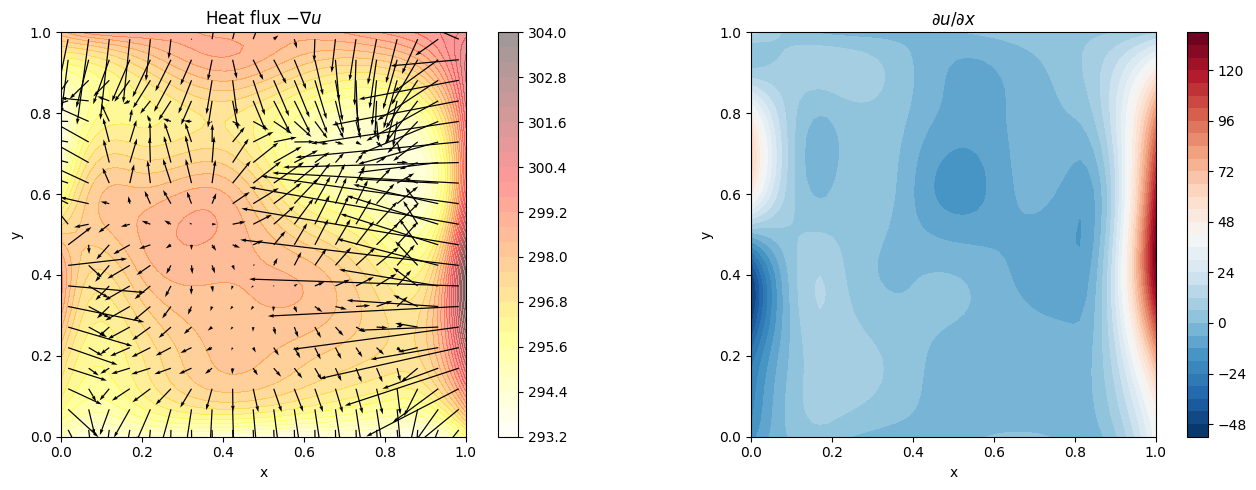

In [15]:
# In NGSolve: Draw(-grad(gfu), mesh, vectors=True)
#             Draw(grad(gfu)[0], mesh)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flux vectors -grad(u)
step = 3
skip = slice(1, -1, step)
c1 = axes[0].contourf(X_bc, Y_bc, U_bc, levels=30, cmap=cm.hot_r, alpha=0.4)
axes[0].quiver(X_bc[skip, skip], Y_bc[skip, skip],
               -GX_bc[skip, skip], -GY_bc[skip, skip],
               color='k', scale=200)
axes[0].set_title('Heat flux $-\\nabla u$')
axes[0].set_aspect('equal')
plt.colorbar(c1, ax=axes[0])

# Gradient x-component
c2 = axes[1].contourf(X_bc, Y_bc, GX_bc, levels=30, cmap=cm.RdBu_r)
axes[1].set_title('$\\partial u / \\partial x$')
axes[1].set_aspect('equal')
plt.colorbar(c2, ax=axes[1])

for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

## Essential boundary conditions

Set $u = u_D$ on $\Gamma_D$, test with $v = 0$ on $\Gamma_D$. Split into Dirichlet/free DOFs:

$$K_{ff} \mathbf{u}_f = \mathbf{f}_f - K_{fD} \mathbf{u}_D$$

For **non-homogeneous** $u_D$: choose $\tilde{u}$ with $\tilde{u}|_{\Gamma_D} = u_D$, solve for correction $w = u - \tilde{u}$:

$$\mathbf{w}_f = K_{ff}^{-1}(\mathbf{f} - \mathbf{K}\tilde{\mathbf{u}})_f$$

### Example: Non-homogeneous Dirichlet + Neumann

We solve $-\Delta u = 0$ on $[0,1]^2$ with Dirichlet on three sides and insulation on top:
- $u_D = \sin(2\pi x)$ on bottom, $u_D = 0$ on left and right
- $\frac{\partial u}{\partial n} = 0$ on top (Neumann, insulation)

In [16]:
# In NGSolve:
#   fes = H1(mesh, order=3, dirichlet="bottom|left|right")
#   a = BilinearForm(grad(u)*grad(v)*dx).Assemble()
#   f = LinearForm(fes)   # nothing here

mp_dir = gs.core.gsMultiPatch()
gs.io.gsReadFile(str(square_xml), mp_dir)
mp_dir.degreeElevate(1)
mp_dir.uniformRefine(4)

patch_dir = mp_dir.patch(0)
basis_dir = patch_dir.basis()
n_dofs_dir = basis_dir.size()
n0_dir = basis_dir.component(0).size()
n1_dir = basis_dir.component(1).size()

# Mark south, west, east as Dirichlet
dir_mapper = gs.core.gsDofMapper(gs.core.gsMultiBasis(mp_dir))
for side_idx in (1, 2, 3):
    side_local = np.array(get_side_dofs(basis_dir, side_idx), dtype=np.int32).reshape(-1, 1)
    dir_mapper.markBoundary(0, side_local, 0)
dir_mapper.finalize()

free_dofs = []
dirichlet_dofs = []
for local_dof in range(n_dofs_dir):
    gid = dir_mapper.index(local_dof, 0, 0)
    if dir_mapper.is_free(local_dof, 0, 0):
        free_dofs.append(gid)
    else:
        dirichlet_dofs.append(gid)
free_dofs = np.array(sorted(free_dofs), dtype=np.int32)
dirichlet_dofs = np.array(sorted(dirichlet_dofs), dtype=np.int32)

# Assemble with the mapper numbering
f_zero = gs.core.gsFunctionExpr('0', 2)
K_dir, F_dir, _ = assemble_poisson(mp_dir, f_zero, mapper=dir_mapper)
gfu_dir = np.zeros(n_dofs_dir)

print(f"DOFs: {n_dofs_dir}, Dirichlet: {len(dirichlet_dofs)}, free: {len(free_dofs)}")

DOFs: 64, Dirichlet: 22, free: 42


Set the Dirichlet values. In NGSolve this would be `gfu.Set(...)`; here we interpolate at the Greville points:

In [17]:
# Set Dirichlet values: sin(2*pi*x) on south, 0 on west/east
uD_expr = gs.core.gsFunctionExpr('sin(2*pi*x)', 2)
greville_0 = basis_dir.knots(0).greville().flatten()
greville_1 = basis_dir.knots(1).greville().flatten()

for local_dof in range(n_dofs_dir):
    if dir_mapper.is_free(local_dof, 0, 0):
        continue
    i = local_dof % n0_dir
    j = local_dof // n0_dir
    xi_g, eta_g = greville_0[i], greville_1[j]
    xy = patch_dir.eval(np.array([[xi_g], [eta_g]]))
    gid = dir_mapper.index(local_dof, 0, 0)
    gfu_dir[gid] = uD_expr.eval(xy).flatten()[0] if j == 0 else 0.0

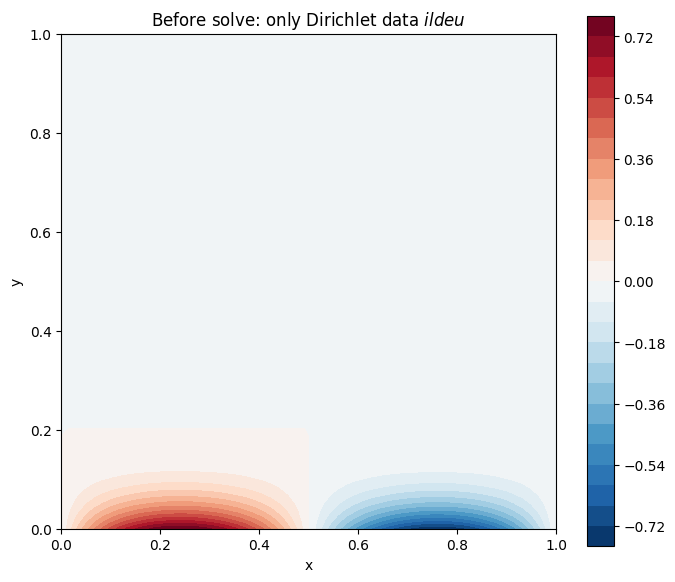

In [18]:
def plot_solution(patch, basis, u_vec, title='', nplot=60, mapper=None, patch_idx=0, comp=0):
    XI, ETA = np.meshgrid(np.linspace(0, 1, nplot), np.linspace(0, 1, nplot))
    params = np.array([XI.ravel(), ETA.ravel()])
    u_h = np.zeros(nplot * nplot)
    for k in range(nplot * nplot):
        pt = params[:, k:k+1]
        act = basis.active(pt).flatten()
        N = basis.eval(pt).flatten()
        if mapper is None:
            u_loc = u_vec[act]
        else:
            gdofs = np.array([mapper.index(int(d), patch_idx, comp) for d in act], dtype=np.int32)
            u_loc = u_vec[gdofs]
        u_h[k] = np.dot(N, u_loc)
    xy = patch.eval(params)
    X = xy[0].reshape(nplot, nplot)
    Y = xy[1].reshape(nplot, nplot)
    U = u_h.reshape(nplot, nplot)
    fig, ax = plt.subplots(figsize=(7, 6))
    c = ax.contourf(X, Y, U, levels=30, cmap=cm.RdBu_r)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(c, ax=ax)
    plt.tight_layout()
    plt.show()

# Before solve: only the Dirichlet data
plot_solution(patch_dir, basis_dir, gfu_dir,
              title='Before solve: only Dirichlet data $\tilde{u}$',
              mapper=dir_mapper)

Compute the correction $\mathbf{w} = K_{ff}^{-1}(\mathbf{f} - \mathbf{K}\tilde{\mathbf{u}})_f$:

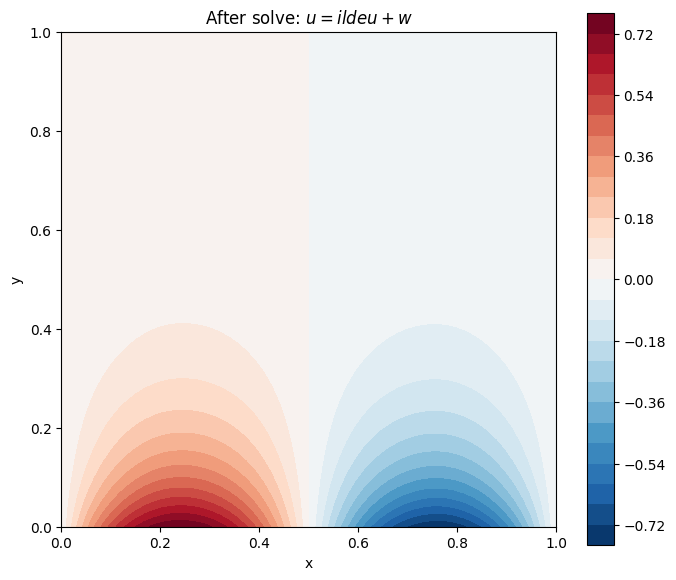

In [19]:
# Residual correction on the free DOFs
residual = F_dir - K_dir @ gfu_dir
K_ff = K_dir[np.ix_(free_dofs, free_dofs)]
gfu_dir[free_dofs] += spsolve(K_ff.tocsc(), residual[free_dofs])

plot_solution(patch_dir, basis_dir, gfu_dir,
              title='After solve: $u = \tilde{u} + w$',
              mapper=dir_mapper)

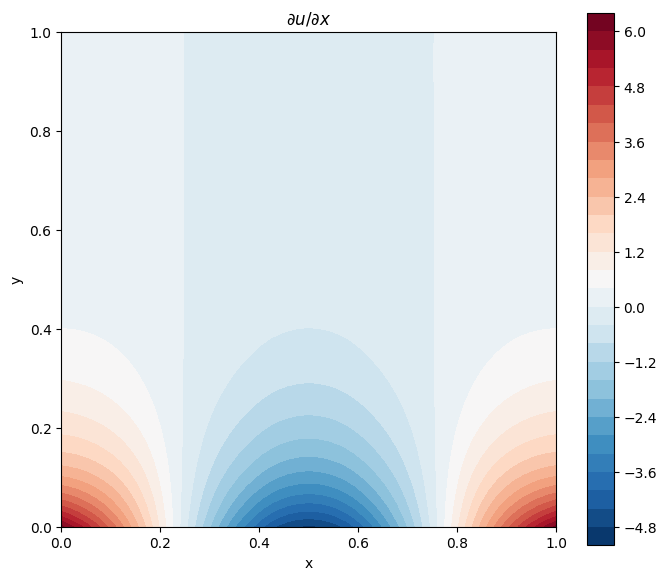

In [20]:
# In NGSolve: Draw(grad(gfu)[0], mesh)
nplot = 60
XI_d, ETA_d = np.meshgrid(np.linspace(0, 1, nplot), np.linspace(0, 1, nplot))
params_d = np.array([XI_d.ravel(), ETA_d.ravel()])

grad_x_d = np.zeros(nplot * nplot)
for k in range(nplot * nplot):
    pt = params_d[:, k:k+1]
    act = basis_dir.active(pt).flatten()
    dN = basis_dir.deriv(pt).flatten().reshape(len(act), 2)
    J = patch_dir.jacobian(pt)
    Jinv_T = np.linalg.inv(J).T
    grad_phys = (Jinv_T @ dN.T).T
    gdofs = np.array([dir_mapper.index(int(d), 0, 0) for d in act], dtype=np.int32)
    grad_u = grad_phys.T @ gfu_dir[gdofs]
    grad_x_d[k] = grad_u[0]

xy_d = patch_dir.eval(params_d)
X_d = xy_d[0].reshape(nplot, nplot)
Y_d = xy_d[1].reshape(nplot, nplot)

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(X_d, Y_d, grad_x_d.reshape(nplot, nplot), levels=30, cmap=cm.RdBu_r)
ax.set_title('$\partial u / \partial x$')
ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(c, ax=ax)
plt.tight_layout()
plt.show()

# Variable Coefficients

$$-\text{div}(\lambda(x) \nabla u) = f, \qquad K_{ij} = \int_{\hat\Omega} \lambda(\mathbf{G}) \, (\mathbf{J}^{-T} \nabla_\xi N_i) \cdot (\mathbf{J}^{-T} \nabla_\xi N_j) \, |\det\mathbf{J}| \, d\boldsymbol{\xi}$$

For discontinuous $\lambda$: temperature continuous, flux $\lambda \nabla u$ continuous across interfaces.

In [21]:
# Variable-coefficient assembly lives in iga_utils.py


### Example: Discontinuous conductivity

We model a domain with a high-conductivity cat-shaped inclusion in the center. The conductivity is $\lambda = 10$ inside the cat and $\lambda = 1$ elsewhere. A heat source $f = 50$ is applied inside the inclusion.

In [22]:
# Variable coefficient problem
mp_var = gs.core.gsMultiPatch()
gs.io.gsReadFile(str(square_xml), mp_var)
mp_var.degreeElevate(1)
mp_var.uniformRefine(5)

patch_var = mp_var.patch(0)
basis_var = patch_var.basis()
n_dofs_var = basis_var.size()
n0_var = basis_var.component(0).size()
n1_var = basis_var.component(1).size()

# --- Cat silhouette from emoji glyph ---
from matplotlib.textpath import TextToPath
from matplotlib.font_manager import FontProperties
from matplotlib.path import Path as MplPath
from matplotlib import transforms

ttp = TextToPath()
verts, codes = ttp.get_text_path(FontProperties(), '\U0001F431')
verts = np.array(verts)

# Normalize to [0,1] and center in the domain
x_min, x_max = verts[:, 0].min(), verts[:, 0].max()
y_min, y_max = verts[:, 1].min(), verts[:, 1].max()
verts_norm = verts.copy()
verts_norm[:, 0] = (verts[:, 0] - x_min) / (x_max - x_min)
verts_norm[:, 1] = (verts[:, 1] - y_min) / (y_max - y_min)

# Scale and center: cat occupies ~0.5 x 0.5 region centered at (0.5, 0.5)
cat_scale = 0.55
verts_norm[:, 0] = 0.5 + (verts_norm[:, 0] - 0.5) * cat_scale
verts_norm[:, 1] = 0.5 + (verts_norm[:, 1] - 0.5) * cat_scale

cat_path = MplPath(verts_norm, codes)
print(f"Cat silhouette: {len(verts)} vertices")

def in_cat(x, y):
    return cat_path.contains_point((x, y))

# Discontinuous conductivity: high inside the cat
def lambda_func(x, y):
    return 10.0 if in_cat(x, y) else 1.0

# Heat source only in the cat
def f_var(x, y):
    return 50.0 if in_cat(x, y) else 0.0

K_var, F_var = assemble_poisson_variable(patch_var, basis_var, lambda_func, f_var)

# Homogeneous Dirichlet on all boundaries
bdry_var = set()
for j in range(n1_var):
    bdry_var.add(j * n0_var)
    bdry_var.add(j * n0_var + n0_var - 1)
for i in range(n0_var):
    bdry_var.add(i)
    bdry_var.add((n1_var - 1) * n0_var + i)
bdry_var = sorted(bdry_var)
inner_var = sorted(set(range(n_dofs_var)) - set(bdry_var))

u_var = np.zeros(n_dofs_var)
F_m = F_var[inner_var]
K_m = K_var[np.ix_(inner_var, inner_var)]
u_var[inner_var] = spsolve(K_m.tocsc(), F_m)

print(f"DOFs: {n_dofs_var}, solution range: [{u_var.min():.4f}, {u_var.max():.4f}]")

Cat silhouette: 226 vertices
DOFs: 81, solution range: [-0.0053, 1.2280]


The temperature is nearly flat inside the high-conductivity cat (small gradient) and the heat flux $-\lambda \nabla u$ is large there:

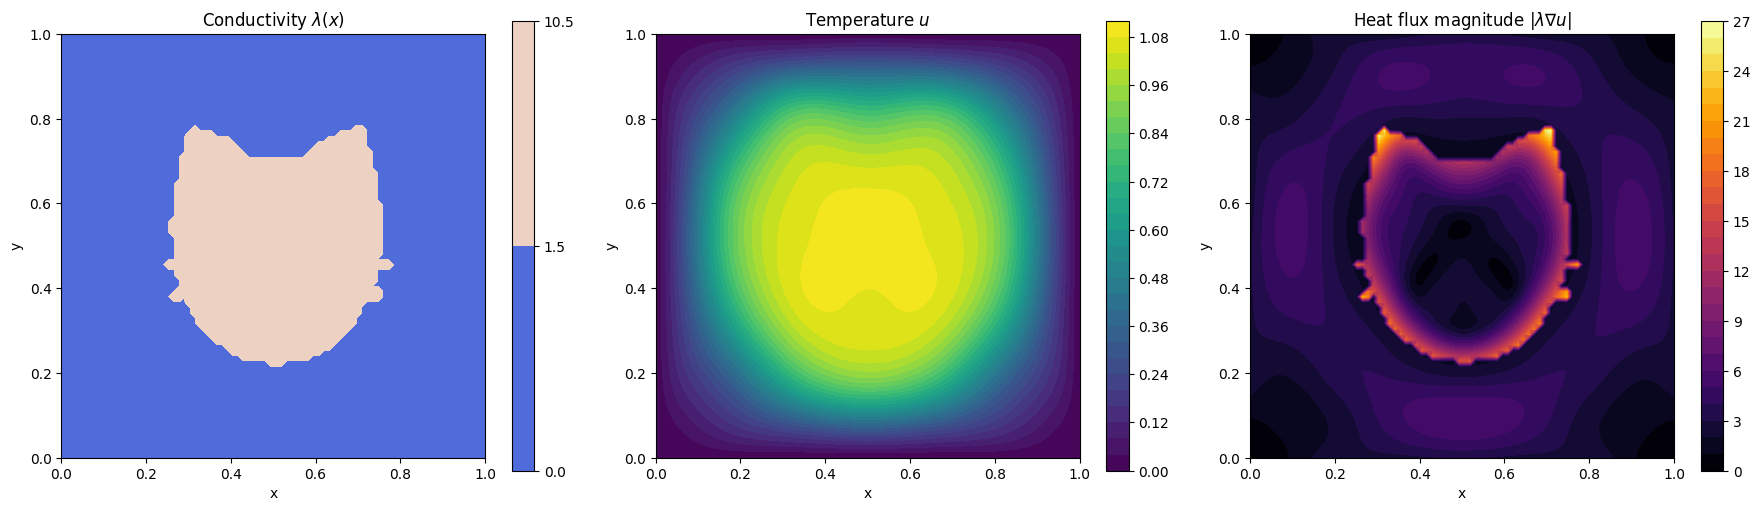

In [23]:
# Visualize temperature and conductivity
nplot = 80
XI_v, ETA_v = np.meshgrid(np.linspace(0, 1, nplot), np.linspace(0, 1, nplot))
params_v = np.array([XI_v.ravel(), ETA_v.ravel()])

u_h_v = np.zeros(nplot * nplot)
for k in range(nplot * nplot):
    pt = params_v[:, k:k+1]
    act = basis_var.active(pt).flatten()
    N = basis_var.eval(pt).flatten()
    u_h_v[k] = np.dot(N, u_var[act])

xy_v = patch_var.eval(params_v)
X_v = xy_v[0].reshape(nplot, nplot)
Y_v = xy_v[1].reshape(nplot, nplot)
U_v = u_h_v.reshape(nplot, nplot)

# Conductivity field
LAM = np.array([lambda_func(xy_v[0, k], xy_v[1, k]) for k in range(nplot**2)]).reshape(nplot, nplot)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c1 = axes[0].contourf(X_v, Y_v, LAM, levels=[0, 1.5, 10.5], cmap='coolwarm')
axes[0].set_title('Conductivity $\\lambda(x)$')
axes[0].set_aspect('equal')
plt.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(X_v, Y_v, U_v, levels=30, cmap=cm.viridis)
axes[1].set_title('Temperature $u$')
axes[1].set_aspect('equal')
plt.colorbar(c2, ax=axes[1])

# Gradient magnitude
grad_mag = np.zeros(nplot * nplot)
for k in range(nplot * nplot):
    pt = params_v[:, k:k+1]
    act = basis_var.active(pt).flatten()
    dN = basis_var.deriv(pt).flatten().reshape(len(act), 2)
    J = patch_var.jacobian(pt)
    Jinv_T = np.linalg.inv(J).T
    grad_phys = (Jinv_T @ dN.T).T
    grad_u = grad_phys.T @ u_var[act]
    xy = patch_var.eval(pt).flatten()
    lam = lambda_func(xy[0], xy[1])
    grad_mag[k] = lam * np.linalg.norm(grad_u)  # |lambda * grad u|

c3 = axes[2].contourf(X_v, Y_v, grad_mag.reshape(nplot, nplot), levels=30, cmap=cm.inferno)
axes[2].set_title('Heat flux magnitude $|\\lambda \\nabla u|$')
axes[2].set_aspect('equal')
plt.colorbar(c3, ax=axes[2])

for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

# Iterative Solvers

For large problems, iterative solvers beat direct solvers. **CG** (Conjugate Gradient) for SPD matrices, with **preconditioner** $P^{-1} \approx K^{-1}$:
- **Jacobi**: $P = \text{diag}(K)$ — cheap, slow
- **Incomplete Cholesky**: sparse approximate factorization — faster convergence

In [25]:
from scipy.sparse.linalg import cg, LinearOperator
from scipy.sparse import diags
import inspect

# Detect whether scipy.cg uses 'tol' or 'rtol' (renamed in scipy >= 1.12)
_cg_params = inspect.signature(cg).parameters
_cg_tol_key = 'rtol' if 'rtol' in _cg_params else 'tol'

def solve_cg(K, F, precond='jacobi', tol=1e-10, maxiter=1000):
    residuals = []

    def callback(xk):
        residuals.append(np.linalg.norm(F - K @ xk))

    # Build preconditioner
    if precond == 'jacobi':
        diag_K = K.diagonal().copy()
        diag_K[diag_K == 0] = 1.0
        M = diags(1.0 / diag_K)
    elif precond == 'ichol':
        from scipy.sparse.linalg import spilu
        ilu = spilu(K.tocsc(), drop_tol=1e-4)
        M = LinearOperator(K.shape, matvec=ilu.solve)
    else:
        M = None

    u, info = cg(K, F, M=M, maxiter=maxiter, callback=callback, **{_cg_tol_key: tol})

    return u, info, residuals

# Parallel Assembly with MPI

Assembly is embarrassingly parallel: $\mathbf{K} = \sum_e \mathbf{K}^{(e)}$. Using `mpi4py`:

In [ ]:
import subprocess, sys, time

# Run with different numbers of MPI ranks
print("Running MPI parallel assembly with mpirun...\n")
result = subprocess.run(
    ["mpirun", "--allow-run-as-root", "-np", "4", sys.executable,
     "parallel_assembly.py", "geometries/curved_channel.xml", "1", "5"],
    capture_output=True, text=True
)
print(result.stdout)
if result.stderr:
    print("stderr:", result.stderr[:500])

### Visualizing the element partitioning

Before running the scaling study, let's visualize how elements are distributed across MPI ranks. Each rank gets elements in **round-robin** order — rank $r$ processes elements $r, r+s, r+2s, \ldots$ This interleaving ensures a roughly equal workload per rank.

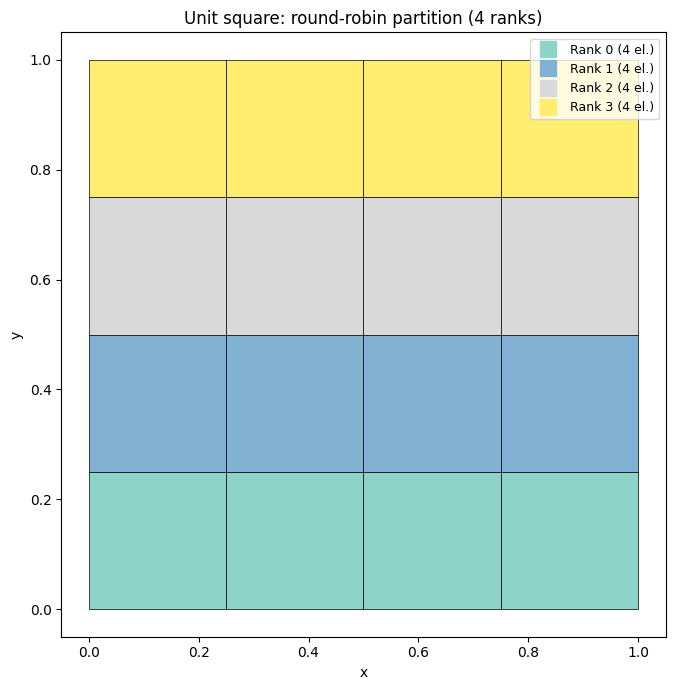

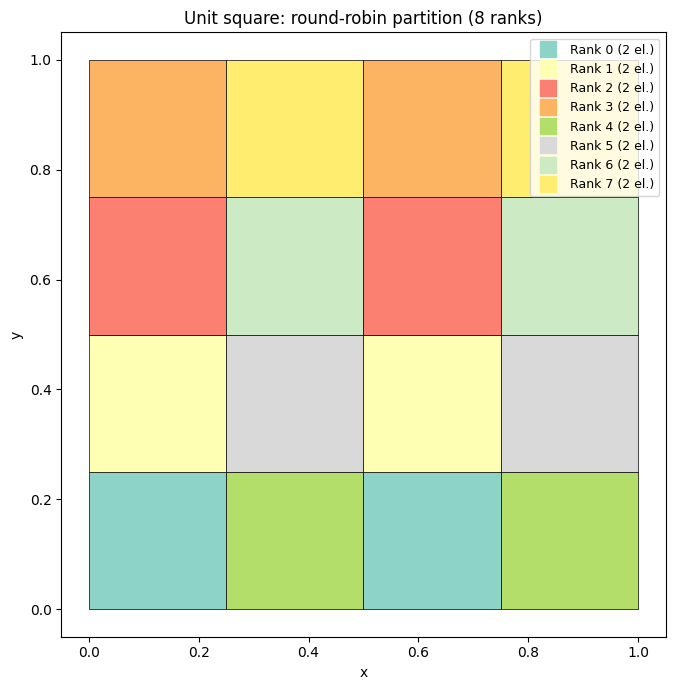

In [195]:
# Visualize element partitioning across MPI ranks
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def plot_element_partition(patch, basis, n_ranks, title=None):
    """Color each element by its assigned MPI rank (round-robin)."""
    breaks_0 = sorted(set(basis.knots(0).get()))
    breaks_1 = sorted(set(basis.knots(1).get()))
    
    all_elements = [(xi_lo, xi_hi, eta_lo, eta_hi)
                    for xi_lo, xi_hi in zip(breaks_0[:-1], breaks_0[1:])
                    for eta_lo, eta_hi in zip(breaks_1[:-1], breaks_1[1:])]
    n_el = len(all_elements)
    
    colors_map = plt.cm.Set3 if n_ranks <= 12 else plt.cm.tab20
    patches = []
    face_colors = []
    
    npts_edge = 10  # points per edge for curved elements
    for idx, (xi_lo, xi_hi, eta_lo, eta_hi) in enumerate(all_elements):
        rank = idx % n_ranks
        
        # Trace element boundary in physical space (for curved geometries)
        edge_pts = []
        for ti in np.linspace(xi_lo, xi_hi, npts_edge):
            xy = patch.eval(np.array([[ti], [eta_lo]])).flatten()
            edge_pts.append(xy)
        for ti in np.linspace(eta_lo, eta_hi, npts_edge):
            xy = patch.eval(np.array([[xi_hi], [ti]])).flatten()
            edge_pts.append(xy)
        for ti in np.linspace(xi_hi, xi_lo, npts_edge):
            xy = patch.eval(np.array([[ti], [eta_hi]])).flatten()
            edge_pts.append(xy)
        for ti in np.linspace(eta_hi, eta_lo, npts_edge):
            xy = patch.eval(np.array([[xi_lo], [ti]])).flatten()
            edge_pts.append(xy)
        
        poly = Polygon(edge_pts, closed=True)
        patches.append(poly)
        face_colors.append(colors_map(rank / max(n_ranks - 1, 1)))
    
    fig, ax = plt.subplots(figsize=(7, 7))
    pc = PatchCollection(patches, facecolors=face_colors, edgecolors='k', linewidths=0.5)
    ax.add_collection(pc)
    ax.autoscale()
    ax.set_aspect('equal')
    
    for r in range(n_ranks):
        ax.plot([], [], 's', color=colors_map(r / max(n_ranks - 1, 1)),
                ms=12, label=f'Rank {r} ({len(all_elements[r::n_ranks])} el.)')
    ax.legend(loc='upper right', fontsize=9)
    
    if title is None:
        title = f'Element partitioning: {n_el} elements across {n_ranks} ranks'
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()

# Show partitioning with 4 and 8 ranks
mp_part = gs.core.gsMultiPatch()
gs.io.gsReadFile(str(square_xml), mp_part)
mp_part.degreeElevate(1)
mp_part.uniformRefine(3)

for n_ranks in [4, 8]:
    plot_element_partition(mp_part.patch(0), mp_part.patch(0).basis(), n_ranks,
                           title=f'Unit square: round-robin partition ({n_ranks} ranks)')

### Scaling: serial vs. MPI parallel

We compare assembly times for the same problem with 1, 2, 4, and 8 MPI ranks:

In [ ]:
import re, os

def run_mpi_assembly(n_ranks, xml_file, p_elevate, num_refine):
    """Run parallel_assembly.py with mpirun and parse output."""
    result = subprocess.run(
        ["mpirun", "--allow-run-as-root", "-np", str(n_ranks), sys.executable,
         "parallel_assembly.py", xml_file, str(p_elevate), str(num_refine)],
        capture_output=True, text=True
    )
    output = result.stdout
    # Parse assembly time
    m = re.search(r'Assembly time:\s+([\d.]+)s', output)
    t_assembly = float(m.group(1)) if m else None
    # Parse L2 error
    m = re.search(r'L2 error:\s+([\d.e+-]+)', output)
    l2_err = float(m.group(1)) if m else None
    return t_assembly, l2_err, output

# Detect physical cores (avoid oversubscription)
n_physical = os.cpu_count() // 2  # logical / 2 for hyperthreading
rank_counts = [1, 2, 4]
if n_physical >= 8:
    rank_counts.append(8)

num_refine = 6
times = []

print(f"{'Ranks':>6s} {'Assembly (s)':>14s} {'Speedup':>10s} {'L2 error':>12s}")
print("-" * 46)

for np_val in rank_counts:
    t, err, _ = run_mpi_assembly(np_val, "geometries/square.xml", 1, num_refine)
    times.append(t)
    speedup = times[0] / t if t and times[0] else 0
    print(f"{np_val:>6d} {t:>14.3f} {speedup:>10.2f}x {err:>12.4e}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rank_counts, times, 'bo-', lw=2, ms=8)
axes[0].set_xlabel('Number of MPI ranks')
axes[0].set_ylabel('Assembly time (s)')
axes[0].set_title('MPI parallel assembly time')
axes[0].grid(True, alpha=0.3)

speedups = [times[0] / t for t in times]
axes[1].plot(rank_counts, speedups, 'bo-', lw=2, ms=8, label='Measured')
axes[1].plot(rank_counts, rank_counts, 'k--', alpha=0.5, label='Ideal')
axes[1].set_xlabel('Number of MPI ranks')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Parallel speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()